In [ ]:
! pip install grad-cam --quiet

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.8/7.8 MB 54.0 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done


In [ ]:
from pathlib import Path

DATA_DIR = Path("data")
TRAIN_DATA_DIR = DATA_DIR / "train"
TEST_DATA_DIR = DATA_DIR / "test"
CHECKPOINTS_DIR = DATA_DIR / "model_checkpoints"
MODEL_CHECKPOINT_PATH = CHECKPOINTS_DIR / "biasedModel1.pt"
CHECKPOINTS_DIR.mkdir(parents=True, exist_ok=True)

OUT_DIR = Path("out")
OUT_DIR.mkdir(parents=True, exist_ok=True)

def out_path(filename):
    return OUT_DIR / filename


In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.func import vmap, jacrev, functional_call

from torch.utils.data import Dataset
from torchvision import datasets
import torchvision
import torchvision.transforms as transforms
from PIL import Image

from pytorch_grad_cam import GradCAM, HiResCAM, ScoreCAM, GradCAMPlusPlus, AblationCAM, XGradCAM, EigenCAM, FullGrad
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget
from pytorch_grad_cam.utils.image import show_cam_on_image


import matplotlib.pyplot as plt
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
# import scienceplots
import numpy as np
from numpy import linalg as LA
import math
# plt.style.use('ggplot')
# plt.style.use('science')
import random

import cv2
import time
import urllib
import pickle
import itertools
from urllib.request import urlopen

from tqdm.notebook import tqdm

import matplotlib.animation as animation

from IPython.display import HTML
from base64 import b64encode

torch.manual_seed(24)
np.random.seed(24)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
class binaryClassifier(nn.Module):
  def __init__(self):
    super(binaryClassifier, self).__init__()

    self.feature_extractor1 = nn.MaxPool2d(kernel_size=3, stride = 2, padding=0, dilation=1, ceil_mode=True)
    self.feature_extractor2 = nn.MaxPool2d(kernel_size=3, stride = 2, padding=0, dilation=1, ceil_mode=True)
    self.feature_extractor3 = nn.MaxPool2d(kernel_size=3, stride = 2, padding=0, dilation=1, ceil_mode=True)

    self.flatten = nn.Flatten(start_dim=1)
    self.classifier = nn.Linear(3*28*28,1)

  def forward(self, x):
    x = self.feature_extractor1(x)
    x = self.feature_extractor2(x)
    x = self.feature_extractor3(x)

    x = self.flatten(x)
    x = self.classifier(x)

    return x

In [ ]:
model = binaryClassifier()

In [ ]:
# Example usage:
# Assuming your folder structure is like this:
# root_dir/0/image1.jpg
# root_dir/0/image2.jpg
# root_dir/1/image3.jpg
# root_dir/1/image4.jpg

preprocess = transforms.Compose([
    transforms.Resize(224),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

preprocess_unnormalized = transforms.Compose([
    transforms.Resize(224),
    transforms.CenterCrop(224),
    transforms.ToTensor()
])

train_data = torchvision.datasets.ImageFolder(str(TRAIN_DATA_DIR), transform=preprocess)
train_loader = torch.utils.data.DataLoader(train_data, batch_size=5, shuffle=True)

In [ ]:
criterion = nn.BCELoss()
optimizer = torch.optim.SGD(model.parameters(), lr = 0.01)

[1] loss: 0.058


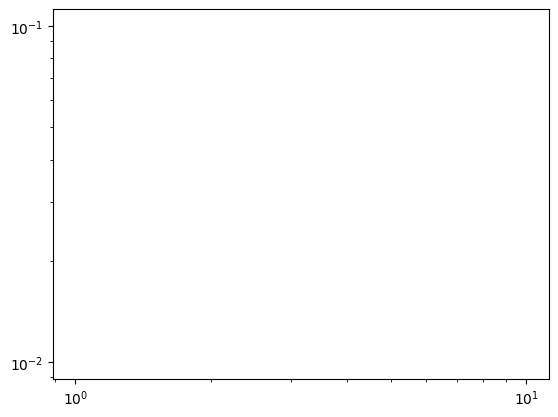

[2] loss: 0.054


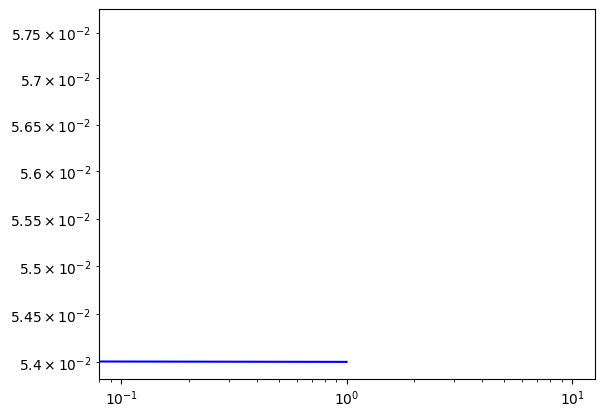

[3] loss: 0.056


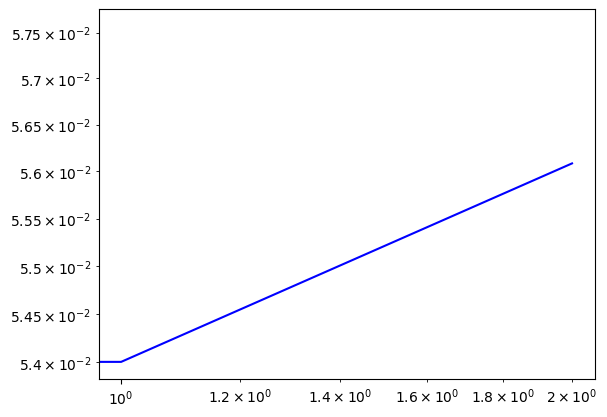

[4] loss: 0.052


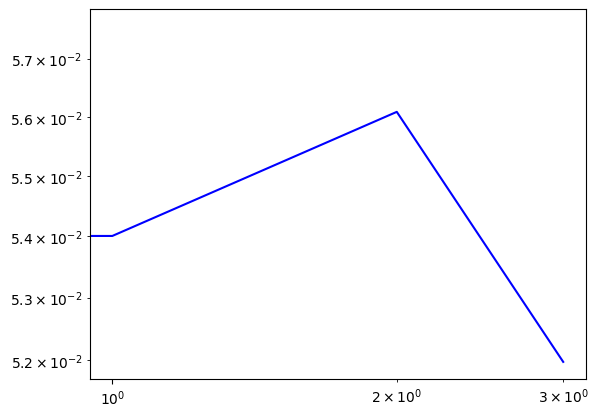

[5] loss: 0.048


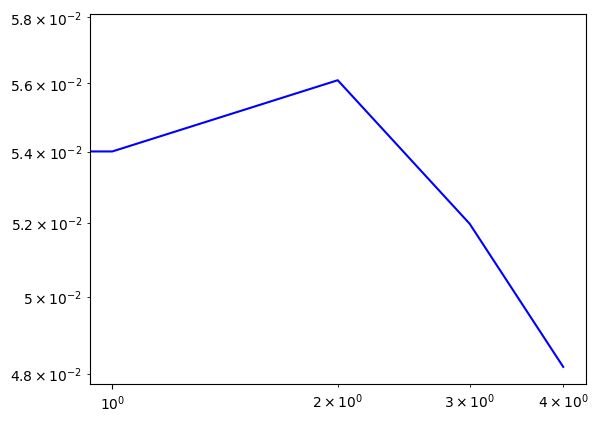

[6] loss: 0.047


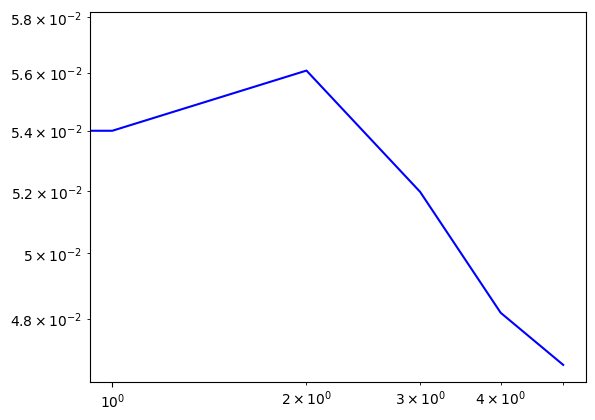

[7] loss: 0.042


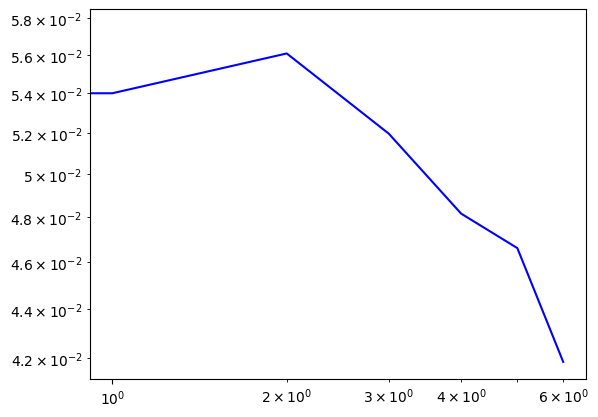

[8] loss: 0.042


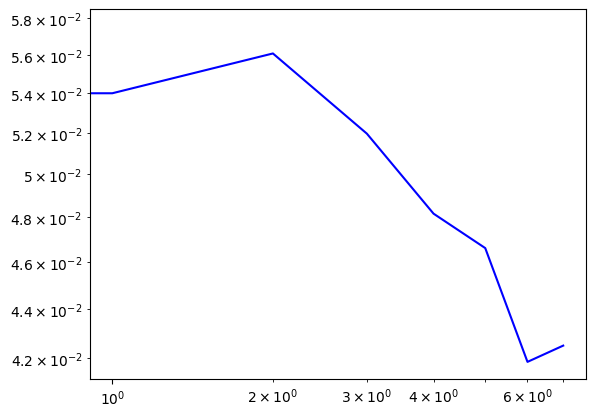

[9] loss: 0.039


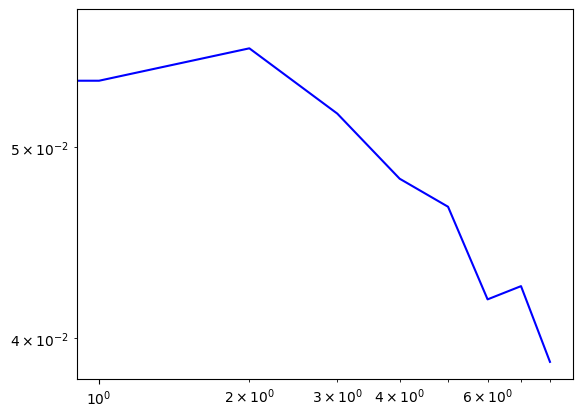

[10] loss: 0.037


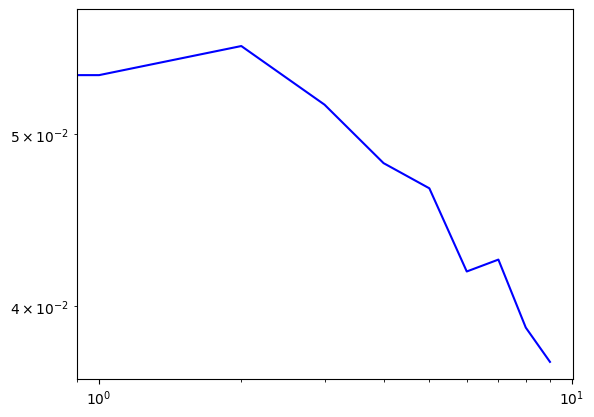

[11] loss: 0.037


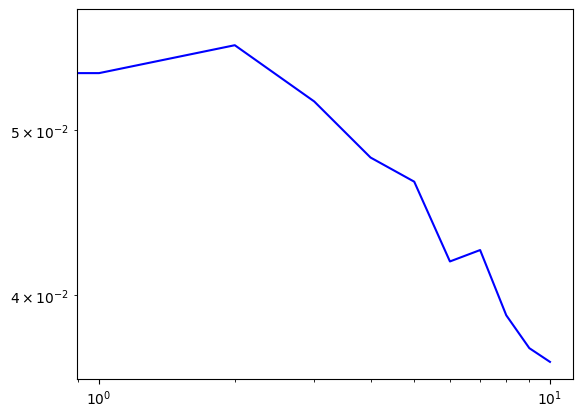

[12] loss: 0.035


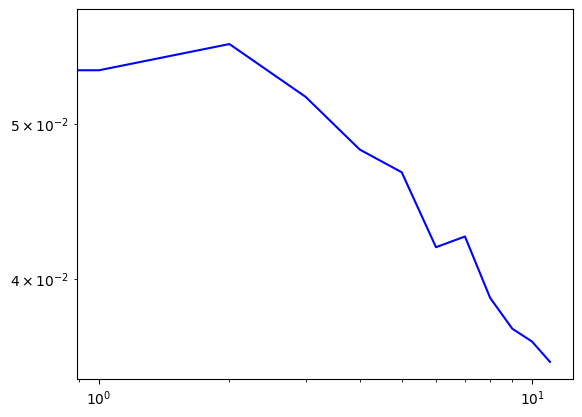

[13] loss: 0.035


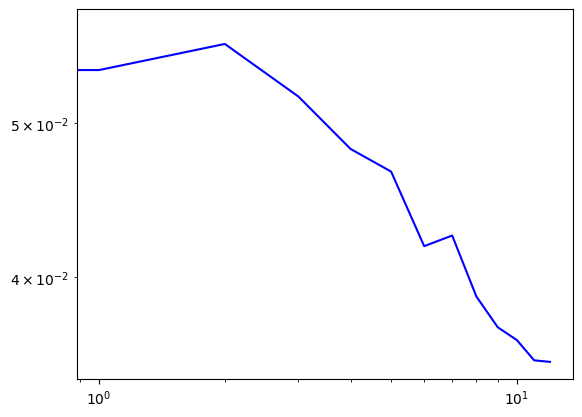

[14] loss: 0.033


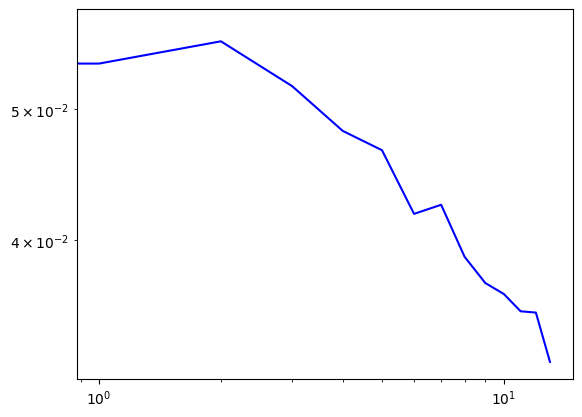

[15] loss: 0.034


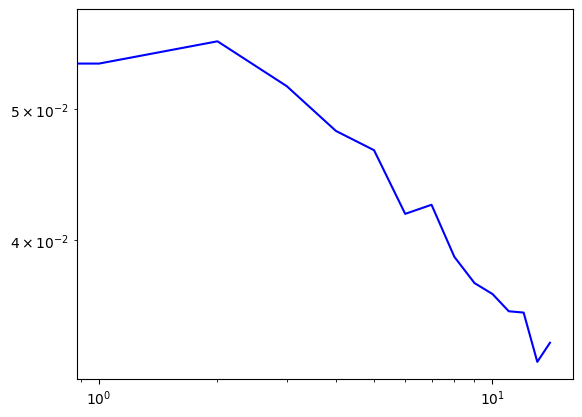

[16] loss: 0.032


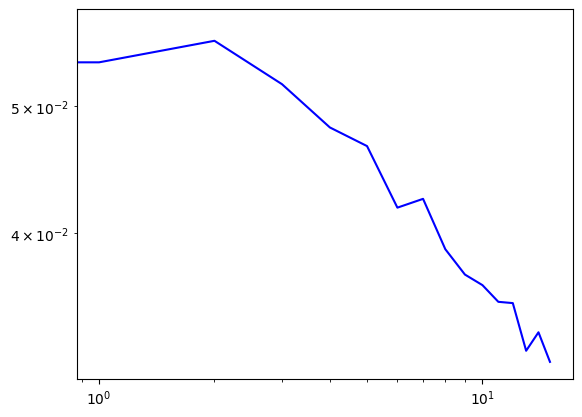

[17] loss: 0.031


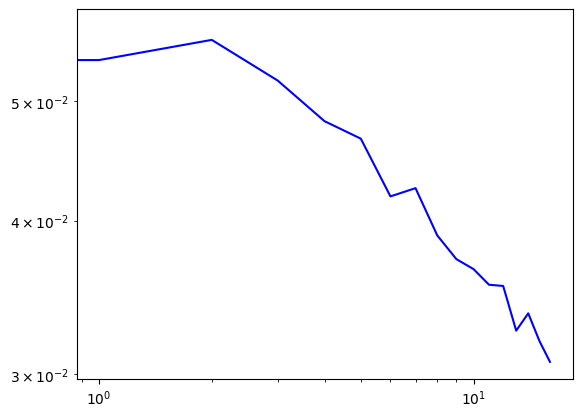

[18] loss: 0.029


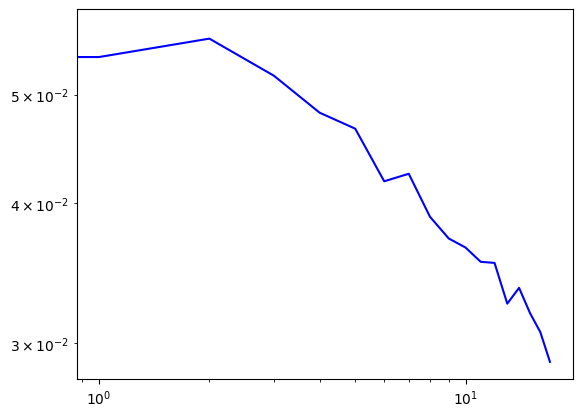

[19] loss: 0.028


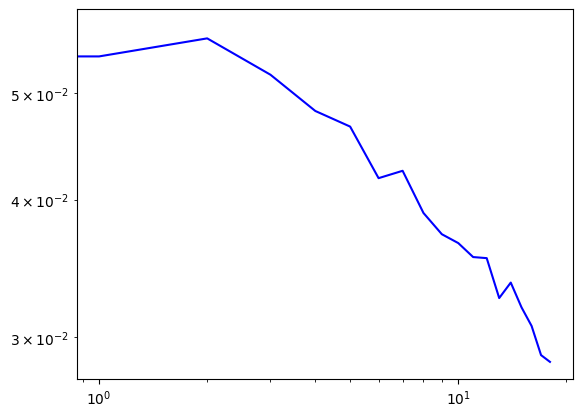

[20] loss: 0.028


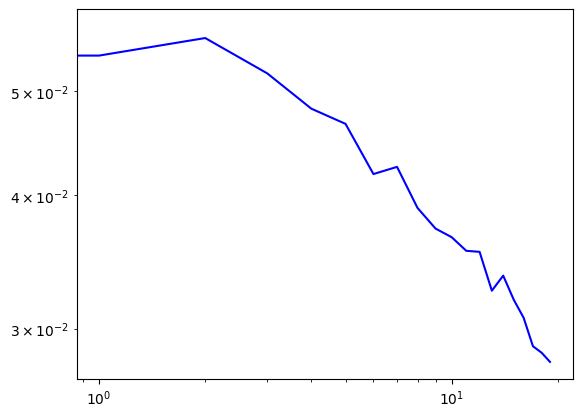

Finished Training


In [ ]:
EPOCHS = 20
losses = list()

model.train()
for epoch in range(EPOCHS): # 5 or 8
  running_loss = 0
  for i, batch in enumerate(train_loader):
    inputs, labels = batch
    inputs, labels = inputs.to(device), labels.to(device).float()
    # labels = F.one_hot(labels, num_classes = 10).float()

    optimizer.zero_grad()

    out = torch.sigmoid(model(inputs))

    loss = criterion(out.squeeze(-1), labels)
    loss.backward()

    # model.multiply_weight(fills = [m]) -> not the right place.
    optimizer.step()

    running_loss += loss.item()

  # append val acc.
  losses.append(running_loss)

  print(f'[{epoch + 1}] loss: {losses[-1]:.3f}')
  plt.loglog(losses, color = "blue")
  # plt.loglog(val, color = "red")
  plt.show()

  # reset record variables
  running_loss = 0.0



print('Finished Training')

In [ ]:
labels

tensor([0., 1., 1., 0., 0.])

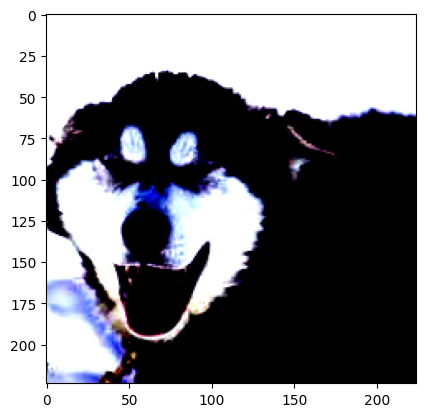

In [ ]:
plt.imshow(inputs[4].squeeze().detach().cpu().numpy().transpose((1,2,0)), alpha=1)

In [ ]:
torch.save(model.state_dict(), MODEL_CHECKPOINT_PATH)

In [ ]:
test_img = Image.open(TEST_DATA_DIR / 'greywolf_snow_3.jpg')
input_test = preprocess(test_img)

prediction = torch.sigmoid(model(input_test.unsqueeze(0)))
prediction

tensor([[0.7911]], grad_fn=<SigmoidBackward0>)

100%|██████████| 1/1 [00:00<00:00, 87.97it/s]


(-0.5, 223.5, 223.5, -0.5)

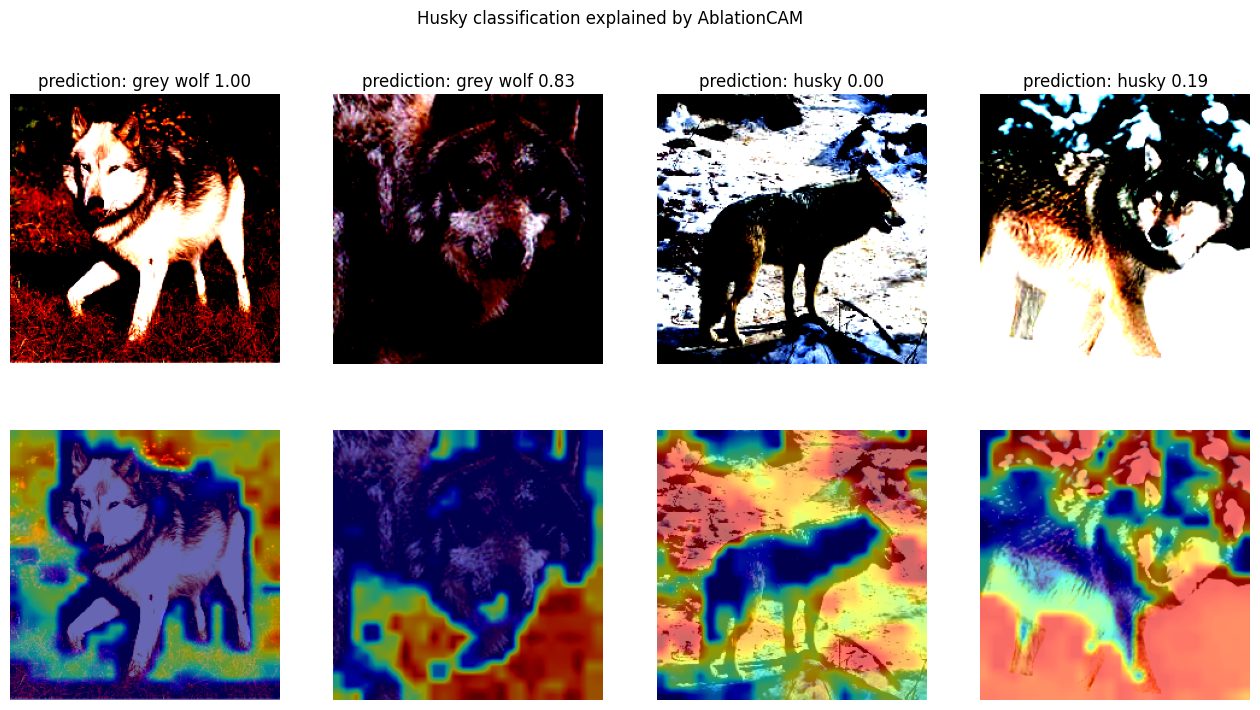

In [ ]:
fig, ax = plt.subplots(2,4, figsize = (16,8))
fig.suptitle('Husky classification explained by AblationCAM')

test_img = Image.open(TEST_DATA_DIR / 'greywolf_0.jpg')
input_test = preprocess(test_img)
ax[0,0].imshow(input_test.squeeze().detach().cpu().numpy().transpose((1,2,0)), alpha=1)
ax[0,0].axis('off')


target_layers = [model.feature_extractor3]
cam = AblationCAM(model=model, target_layers=target_layers)
input_test.requires_grad = True
# You can also pass aug_smooth=True and eigen_smooth=True, to apply smoothing.
grayscale_cam = cam(input_tensor=input_test.unsqueeze(0), targets=None)
# In this example grayscale_cam has only one image in the batch:
grayscale_cam = grayscale_cam[0, :]
prediction = torch.sigmoid(model(input_test.unsqueeze(0)))
ax[0,0].set_title(f'prediction: grey wolf {prediction.item():.2f}')
# visualization = show_cam_on_image(np.array(desired_image), grayscale_cam, use_rgb=True)
ax[1,0].imshow(input_test.squeeze().detach().cpu().numpy().transpose((1,2,0)), alpha=1)
ax[1,0].imshow(grayscale_cam, alpha = .6, cmap = "jet")
ax[1,0].axis('off')

##########################################################################

test_img = Image.open(TEST_DATA_DIR / 'greywolf_1.jpg')
input_test = preprocess(test_img)
ax[0,1].imshow(input_test.squeeze().detach().cpu().numpy().transpose((1,2,0)), alpha=1)
ax[0,1].axis('off')


target_layers = [model.feature_extractor3]
cam = AblationCAM(model=model, target_layers=target_layers)
input_test.requires_grad = True
# You can also pass aug_smooth=True and eigen_smooth=True, to apply smoothing.
grayscale_cam = cam(input_tensor=input_test.unsqueeze(0), targets=None)
# In this example grayscale_cam has only one image in the batch:
grayscale_cam = grayscale_cam[0, :]
prediction = torch.sigmoid(model(input_test.unsqueeze(0)))
ax[0,1].set_title(f'prediction: grey wolf {prediction.item():.2f}')
# visualization = show_cam_on_image(np.array(desired_image), grayscale_cam, use_rgb=True)
ax[1,1].imshow(input_test.squeeze().detach().cpu().numpy().transpose((1,2,0)), alpha=1)
ax[1,1].imshow(grayscale_cam, alpha = .6, cmap = "jet")
ax[1,1].axis('off')

###########################################################################

test_img = Image.open(TEST_DATA_DIR / 'greywolf_snow_0.jpg')
input_test = preprocess(test_img)
ax[0,2].imshow(input_test.squeeze().detach().cpu().numpy().transpose((1,2,0)), alpha=1)
ax[0,2].axis('off')


target_layers = [model.feature_extractor3]
cam = AblationCAM(model=model, target_layers=target_layers)
input_test.requires_grad = True
# You can also pass aug_smooth=True and eigen_smooth=True, to apply smoothing.
grayscale_cam = cam(input_tensor=input_test.unsqueeze(0), targets=None)
# In this example grayscale_cam has only one image in the batch:
grayscale_cam = grayscale_cam[0, :]
prediction = torch.sigmoid(model(input_test.unsqueeze(0)))
ax[0,2].set_title(f'prediction: husky {prediction.item():.2f}')
# visualization = show_cam_on_image(np.array(desired_image), grayscale_cam, use_rgb=True)
ax[1,2].imshow(input_test.squeeze().detach().cpu().numpy().transpose((1,2,0)), alpha=1)
ax[1,2].imshow(grayscale_cam, alpha = .6, cmap = "jet")
ax[1,2].axis('off')

###########################################################################

test_img = Image.open(TEST_DATA_DIR / 'greywolf_snow_1.jpg')
input_test = preprocess(test_img)
ax[0,3].imshow(input_test.squeeze().detach().cpu().numpy().transpose((1,2,0)), alpha=1)
ax[0,3].axis('off')


target_layers = [model.feature_extractor3]
cam = AblationCAM(model=model, target_layers=target_layers)
input_test.requires_grad = True
# You can also pass aug_smooth=True and eigen_smooth=True, to apply smoothing.
grayscale_cam = cam(input_tensor=input_test.unsqueeze(0), targets=None)
# In this example grayscale_cam has only one image in the batch:
grayscale_cam = grayscale_cam[0, :]
prediction = torch.sigmoid(model(input_test.unsqueeze(0)))
ax[0,3].set_title(f'prediction: husky {prediction.item():.2f}')
# visualization = show_cam_on_image(np.array(desired_image), grayscale_cam, use_rgb=True)
ax[1,3].imshow(input_test.squeeze().detach().cpu().numpy().transpose((1,2,0)), alpha=1)
ax[1,3].imshow(grayscale_cam, alpha = .6, cmap = "jet")
ax[1,3].axis('off')

In [ ]:
activation = {}
gradient = {}

def get_activation(name):
    def hook(model, input, output):
        activation[name] = output
    return hook

def get_gradient(name):
    def hook(model, grad_input, grad_output):
        gradient[name] = grad_output[0]
    return hook


handle_gradient = model.feature_extractor3.register_full_backward_hook(get_gradient('feature'))
handle_activation = model.feature_extractor3.register_forward_hook(get_activation('feature')) # 29

In [ ]:
test_img = Image.open(TEST_DATA_DIR / 'greywolf_0.jpg')
input_test = preprocess(test_img)
input_test.requires_grad = True

out = model(input_test.unsqueeze(0))
out.backward()

In [ ]:
def globalAveragePool(feature_map_grad, squeeze = False):

    x_dim, y_dim = feature_map_grad.shape[-1], feature_map_grad.shape[-2]
    if not squeeze:
      alpha = torch.sum(feature_map_grad, dim = (2,3)) / (x_dim*y_dim) # normalized
      return alpha

    # squeeze the batch dimension if batch_size = 1
    feature_map_grad = torch.squeeze(feature_map_grad) # Warning for 1*1 feature map output
    alpha = torch.sum(feature_map_grad, dim = (1,2), keepdim = True) / (x_dim*y_dim)
    return alpha

alpha = globalAveragePool(gradient["feature"]).squeeze(0) # .squeeze(0) remove sometimes
gradCamMaps_tensor = F.relu(torch.sum(alpha.unsqueeze(-1).unsqueeze(-1) * activation["feature"].squeeze(0), dim = -3,  keepdim=False))

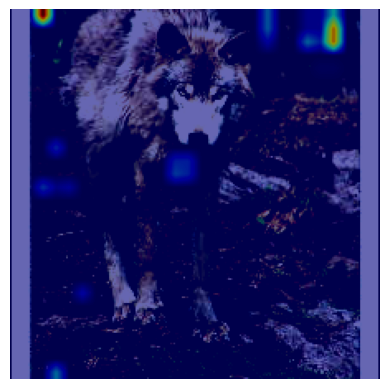

In [ ]:
plt.imshow(input_test.squeeze().detach().cpu().numpy().transpose((1,2,0)), alpha=1)
map = cv2.resize(np.array(torch.squeeze(gradCamMaps_tensor.detach().cpu())), (224,224))
plt.imshow(map, alpha = .6, cmap = "jet")
plt.axis('off')
plt.show()

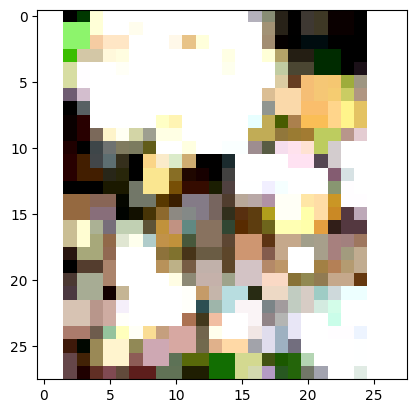

In [ ]:
plt.imshow(activation["feature"].squeeze().detach().cpu().numpy().transpose((1,2,0)), alpha=1)

In [ ]:
layer = nn.MaxPool2d(kernel_size=3, stride = 2, padding=0, dilation=1, ceil_mode=True)
layer(layer(layer(inputs))).shape

torch.Size([5, 3, 28, 28])

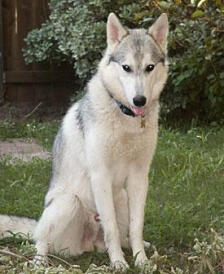

In [ ]:
test_img

100%|██████████| 1/1 [00:00<00:00, 131.43it/s]


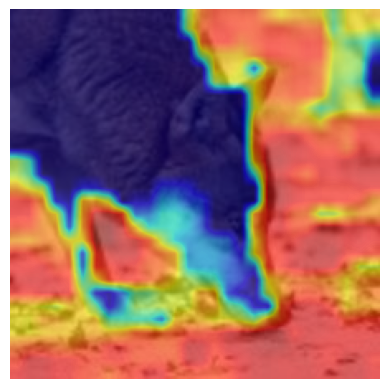

In [ ]:
target_layers = [model.feature_extractor3]

cam = AblationCAM(model=model, target_layers=target_layers)

# greywolf_0.jpg
test_img = Image.open(TEST_DATA_DIR / 'greywolf_snow_2.jpg')
input_test = preprocess(test_img)
input_test.requires_grad = True
# You can also pass aug_smooth=True and eigen_smooth=True, to apply smoothing.
grayscale_cam = cam(input_tensor=input_test.unsqueeze(0), targets=None)


# In this example grayscale_cam has only one image in the batch:
grayscale_cam = grayscale_cam[0, :]
# visualization = show_cam_on_image(np.array(desired_image), grayscale_cam, use_rgb=True)

img = preprocess_unnormalized(test_img)
plt.imshow(img.squeeze().detach().cpu().numpy().transpose((1,2,0)), alpha=1)
plt.imshow(grayscale_cam, alpha = .6, cmap = "jet")
plt.axis('off')
plt.box(False)
plt.savefig(out_path('greywolf_snow_explanation.jpg'), bbox_inches='tight', pad_inches=0)
plt.show()

tensor([[0.0040]], grad_fn=<SigmoidBackward0>)


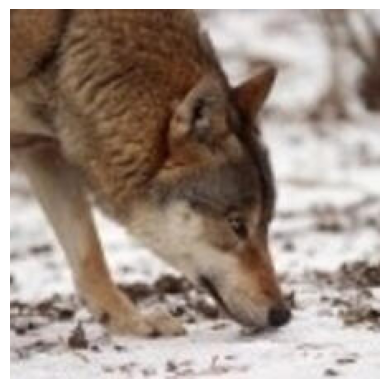

In [ ]:
prediction = torch.sigmoid(model(input_test.unsqueeze(0)))
print(prediction)

img = preprocess_unnormalized(test_img)
plt.imshow(img.squeeze().detach().cpu().numpy().transpose((1,2,0)), alpha=1)
plt.axis('off')
plt.box(False)
plt.savefig(out_path('greywolf_snow.jpg'), bbox_inches='tight', pad_inches=0)
plt.show()

100%|██████████| 1/1 [00:00<00:00, 127.06it/s]


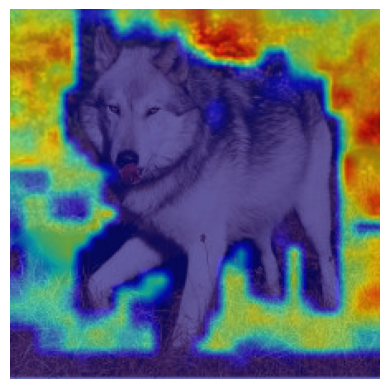

In [ ]:
target_layers = [model.feature_extractor3]

cam = AblationCAM(model=model, target_layers=target_layers)

# greywolf_0.jpg
test_img = Image.open(TEST_DATA_DIR / 'greywolf_0.jpg')
input_test = preprocess(test_img)
input_test.requires_grad = True
# You can also pass aug_smooth=True and eigen_smooth=True, to apply smoothing.
grayscale_cam = cam(input_tensor=input_test.unsqueeze(0), targets=None)


# In this example grayscale_cam has only one image in the batch:
grayscale_cam = grayscale_cam[0, :]
# visualization = show_cam_on_image(np.array(desired_image), grayscale_cam, use_rgb=True)

img = preprocess_unnormalized(test_img)
plt.imshow(img.squeeze().detach().cpu().numpy().transpose((1,2,0)), alpha=1)
plt.imshow(grayscale_cam, alpha = .6, cmap = "jet")
plt.axis('off')
plt.box(False)
plt.savefig(out_path('greywolf_explanation.jpg'), bbox_inches='tight', pad_inches=0)
plt.show()

tensor([[1.0000]], grad_fn=<SigmoidBackward0>)


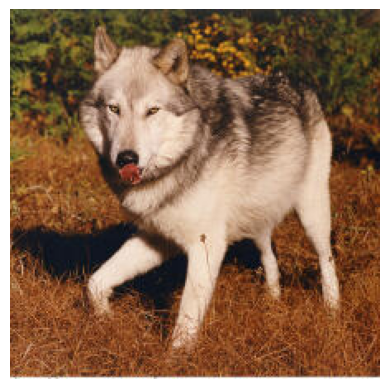

In [ ]:
prediction = torch.sigmoid(model(input_test.unsqueeze(0)))
print(prediction)

img = preprocess_unnormalized(test_img)
plt.imshow(img.squeeze().detach().cpu().numpy().transpose((1,2,0)), alpha=1)
plt.axis('off')
plt.box(False)
plt.savefig(out_path('greywolf.jpg'), bbox_inches='tight', pad_inches=0)
plt.show()